In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../../Modules/")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [3]:
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv'

dataset = read_data(path)
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,23.812763,38.047451,1,2010,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,8.761039,11.580251,5.941828,0.578889,17.782222,10.733185,NaN,NaN,NaN,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,120.039680,25.307650,42.361009,47.792020,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN,2164.888889,0
1,23.685082,38.018504,1,2010,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,10.493728,13.860538,7.126918,1.052222,19.014444,12.935874,NaN,NaN,NaN,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,112.130405,23.686240,39.818155,44.482084,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN,2596.888889,0
2,23.754944,37.979104,1,2010,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,9.753346,12.876044,6.630647,0.379474,18.605789,11.901135,NaN,NaN,NaN,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,112.993420,23.831676,39.924151,44.652948,64868.0,377784.0,79042.0,521694.0,61544.0,388717.0,118883.0,569144.0,39021.83,NaN,NaN,2375.526316,0
3,23.749555,37.914897,1,2010,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,9.072484,12.310000,5.834968,-2.668000,19.224000,11.720357,NaN,NaN,NaN,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,110.246915,23.460094,39.829571,44.335911,38993.0,183267.0,41033.0,263293.0,36789.0,199070.0,55549.0,291408.0,12606.74,NaN,NaN,2468.400000,0
4,23.889386,38.042726,1,2010,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,8.701736,11.589957,5.813515,1.772276,18.574390,10.720874,NaN,NaN,NaN,13.768236,NaN,NaN,NaN,7.672467,NaN,NaN,NaN,3.905487,121.070102,25.460487,41.766648,46.576365,43417.0,180372.0,35396.0,259185.0,41239.0,171976.0,38828.0,252043.0,13091.44,NaN,NaN,2098.851724,0


In [4]:
dataset.shape

(1092, 75)

In [5]:
dataset = encode_cyclical(dataset, 'month', 12)
dataset = convert_multiple_cases(dataset, target_col='cases')

In [6]:
dataset.cases.unique()

array([0, 1], dtype=int64)

In [7]:
dataset.shape

(1321, 77)

In [8]:
dataset.rename(columns={"cases": "case"}, inplace=True)

In [9]:
dataset.columns

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [10]:
print(f'Number of NUTS3 Units in {NUTS2}: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in Attica: 7


In [11]:
dsc = dataframe_describe(dataset, target_column = 'case')
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,84,0,84,6.36%
1,2011,71,30,101,7.65%
2,2012,75,45,120,9.08%
3,2013,75,35,110,8.33%
4,2014,83,2,85,6.43%
5,2015,84,0,84,6.36%
6,2016,84,0,84,6.36%
7,2017,84,0,84,6.36%
8,2018,59,155,214,16.20%
9,2019,79,24,103,7.80%


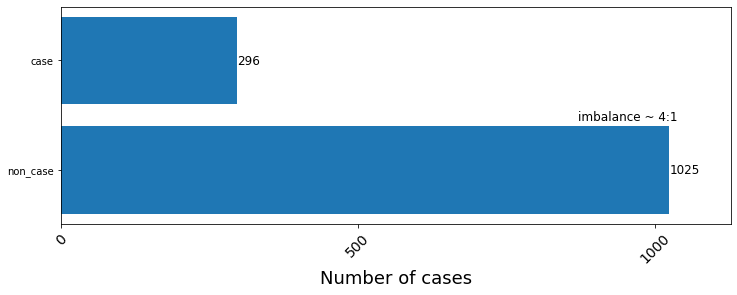

In [12]:
plot_imbalance(dataset, target_column='case')

In [13]:
majority_class = 0
near_u = 0
smote = 0.1
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = [2010, 2015, 2016, 2017, 2022]
features_to_remove = ['x', 'y','month', 'year','L_TOTAL', 'UNL_TOTAL',]

In [14]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lst', 'lst_day', 'lst_night', 'monthly_lst_min',
       'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
       'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
       'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'M_Y_LT15', 'M_Y15-64',
       'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL',
       'MIO_EUR', 'mosq_pred', 'month_sin', 'month_cos'],
      dtype='object')


In [15]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, scaler_key = scaler, majority_class = majority_class, exclude_features=features_to_remove)
        
    w0,w1 = calculate_weights_new(y_train, weight_multiplier)
    #w0, w1 = 1, 1

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, spatial_col = 'NUTS3_NAME')
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)

    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

shap_values= np.concatenate(model_shaps, axis=0)

Year: 2010 || w0:1, w1:2 || ##
Year: 2011 || w0:1, w1:2 || ##
Year: 2012 || w0:1, w1:2 || ##
Year: 2013 || w0:1, w1:2 || ##
Year: 2014 || w0:1, w1:2 || ##
Year: 2015 || w0:1, w1:2 || ##
Year: 2016 || w0:1, w1:2 || ##
Year: 2017 || w0:1, w1:2 || ##
Year: 2018 || w0:1, w1:4 || ##
Year: 2019 || w0:1, w1:2 || ##
Year: 2020 || w0:1, w1:2 || ##
Year: 2021 || w0:1, w1:2 || ##
Year: 2022 || w0:1, w1:2 || ##


In [16]:
feature_names

Index(['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lst', 'lst_day', 'lst_night', 'monthly_lst_min',
       'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
       'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
       'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'M_Y_LT15', 'M_Y15-64',
       'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL',
       'MIO_EUR', 'mosq_pred', 'month_sin', 'month_cos'],
      dtype='object')

In [17]:
len(feature_names)

65

In [18]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9',
               'bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']

weather = ['lst', 'lst_day', 'lst_night',
           'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean',
           'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
           'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
           'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
           'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
           'acc_rainfall_2week', 'acc_rainfall_jan']

indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
            'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
            'ndbi_std',]

demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']

vectors = ['mosq_pred']

trade = ['L_TOTAL',	'UNL_TOTAL']

economic = ['MIO_EUR']

spatiotemporal = ['month_sin', 'month_cos', 'x', 'y']

In [19]:
len(indicies + weather + demographic + bioclimatic + spatiotemporal + vectors + trade + economic)

69

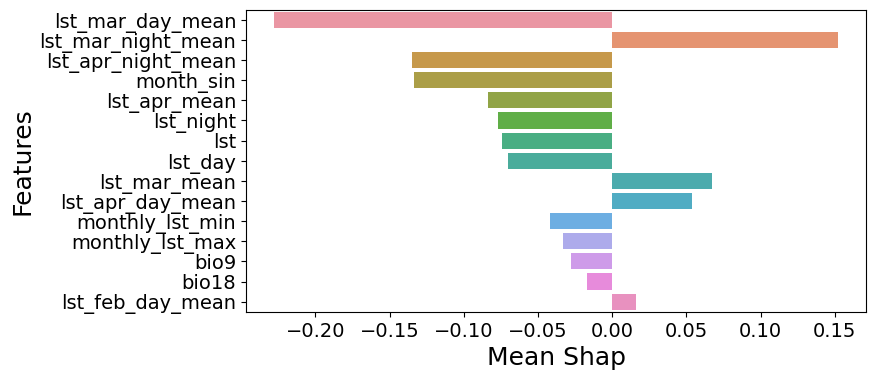

In [20]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

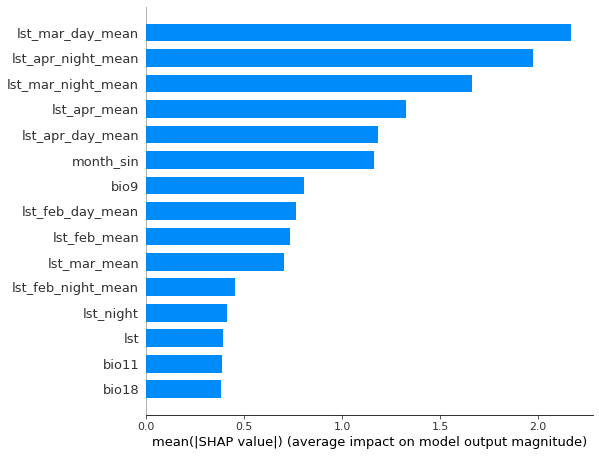

In [21]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

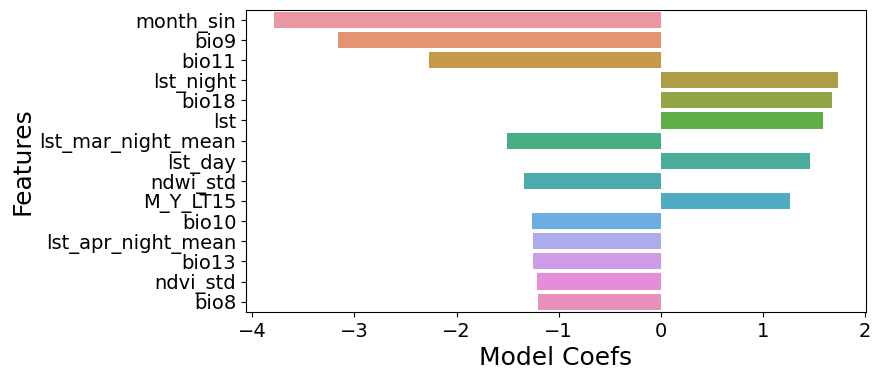

In [22]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

In [23]:
len(indicies + weather + demographic + bioclimatic + spatiotemporal + vectors + trade + economic)

69

,features,weights
4,spatiotemporal,0.071760
1,weather,0.048805
5,vectors,0.011512
3,bioclimatic,0.006024
0,rs_indicies,0.005521
2,demographic,0.001810
7,economic,0.000501
6,trade,NaN


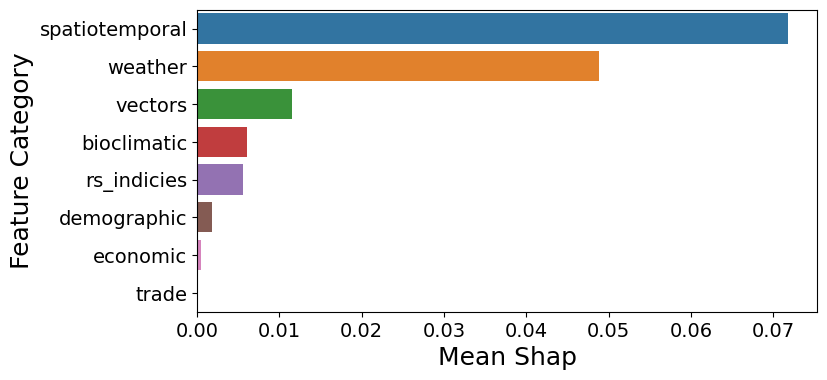

In [24]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_weather = shaps.loc[shaps['features'].isin(weather)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['rs_indicies', 'weather', 
                           'demographic', 'bioclimatic', 
                           'spatiotemporal', 'vectors',
                           'trade', 'economic'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_weather.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_bioclimatic.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_vectors.weights_abs.mean(),
                            df_trade.weights_abs.mean(),df_economic.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,8)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

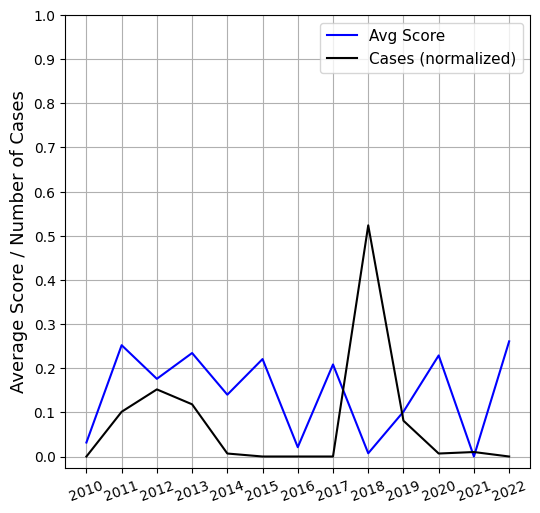

In [25]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

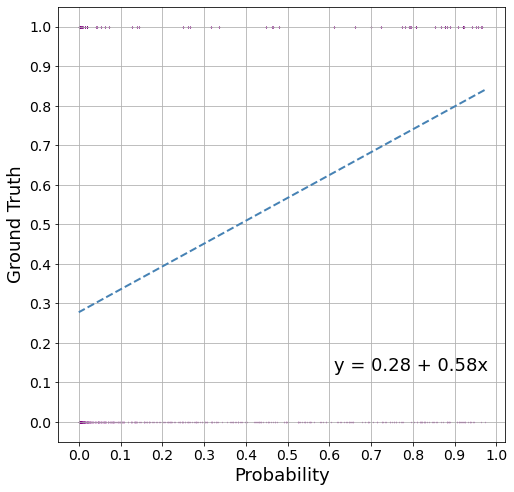

(0.2777068413369775, 0.5784763881670368)

In [26]:
plot_probability_curve(results_test)

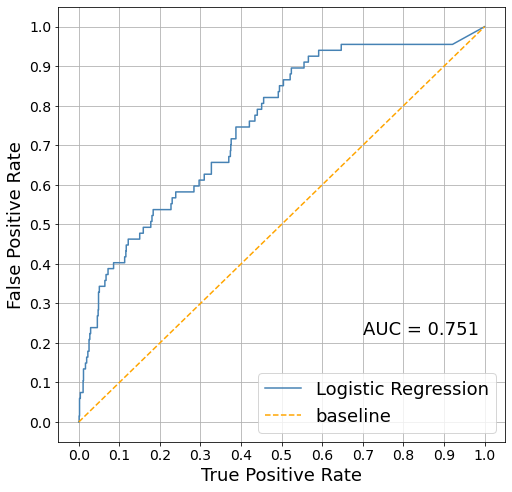

(0.3873, 0.7463, 0.0147, 0.6762)

In [27]:
plot_roc_curve(results_test, plot_gmean=False)

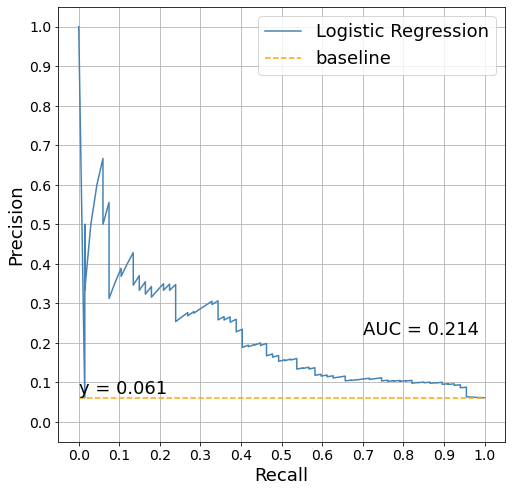

(0.5373, 0.16, 0.25, 0.3659)

In [28]:
plot_pr_curve(results_test, plot_fbeta = False)

In [29]:
results_test

,NUTS3_NAME,month,year,case,score
0,ανατολικη αττικη,8,2015,0,0.971571
1,ανατολικη αττικη,8,2011,1,0.966307
2,ανατολικη αττικη,8,2022,0,0.963771
3,ανατολικη αττικη,8,2013,1,0.963685
4,ανατολικη αττικη,9,2011,1,0.956179
...,...,...,...,...,...
1087,δυτικη αττικη,5,2021,0,0.000000
1088,ανατολικη αττικη,5,2021,0,0.000000
1089,νοτιος τομεας αθηνων,5,2021,0,0.000000
1090,κεντρικος τομεας αθηνων,5,2021,0,0.000000


In [30]:
results_test.head(30)

,NUTS3_NAME,month,year,case,score
0,θεσσαλονικη,8,2015,0,0.998573
1,θεσσαλονικη,9,2015,0,0.997622
2,ημαθια,8,2015,0,0.996148
3,θεσσαλονικη,7,2015,0,0.994786
4,πελλα,8,2015,0,0.994383
5,ημαθια,9,2015,0,0.994011
6,θεσσαλονικη,9,2020,1,0.993722
7,πιερια,8,2015,0,0.992013
8,πελλα,9,2015,0,0.991887
9,θεσσαλονικη,8,2012,1,0.990029
